<a href="https://colab.research.google.com/github/venkatasriharika-code/movie_recommendation_system/blob/main/movie_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
movies_data = {
    'MovieID': range(1, 26),
    'Title': [
        'The Dark Knight', 'Inception', 'Interstellar', 'The Matrix',
        'Avengers: Endgame', 'Iron Man', 'Spider-Man', 'Thor',
        'Titanic', 'The Notebook', 'La La Land', 'Pride & Prejudice',
        'The Shawshank Redemption', 'Forrest Gump', 'Schindler\'s List', 'The Godfather',
        'Toy Story', 'Finding Nemo', 'The Lion King', 'Shrek',
        'Get Out', 'A Quiet Place', 'The Conjuring', 'It',
        'Parasite'
    ],
    'Genre': [
        'Action Thriller Crime', 'Action SciFi Thriller', 'SciFi Drama Adventure', 'Action SciFi',
        'Action Adventure SciFi', 'Action SciFi Adventure', 'Action Adventure', 'Action Adventure Fantasy',
        'Romance Drama', 'Romance Drama', 'Romance Drama Music', 'Romance Drama',
        'Drama Crime', 'Drama Romance Comedy', 'Drama History War', 'Crime Drama',
        'Animation Comedy Adventure', 'Animation Comedy Adventure', 'Animation Drama Adventure', 'Animation Comedy Fantasy',
        'Horror Thriller Mystery', 'Horror SciFi Thriller', 'Horror Mystery', 'Horror',
        'Drama Thriller Crime'
    ],
    'Rating': [9.0, 8.8, 8.6, 8.7, 8.4, 7.9, 7.4, 7.0,
               7.8, 7.9, 8.0, 7.8,
               9.3, 8.8, 9.0, 9.2,
               8.3, 8.2, 8.5, 7.9,
               7.7, 7.5, 7.5, 6.9,
               8.5],
    'Votes': [2800000, 2300000, 1900000, 1800000,
              1200000, 1000000,  800000,  700000,
               900000,  600000,  700000,  500000,
              2700000, 2100000, 1400000, 2000000,
               900000,  950000, 1000000,  750000,
               700000,  600000,  500000,  400000,
               800000],
    'Description': [
        'Batman fights the Joker in Gotham city dark hero vigilante',
        'Dream thief enters subconscious mind layers reality illusion',
        'Astronauts travel wormhole space time gravity black hole',
        'Hacker discovers reality is simulation artificial intelligence machines',
        'Superheroes assemble fight Thanos save universe infinity stones',
        'Billionaire builds suit armor becomes superhero technology',
        'Teenager bitten spider gains powers protects New York city',
        'Norse god banished Earth hammer lightning Asgard Loki',
        'Love story ship iceberg tragedy ocean Rose Jack',
        'Small town love story second chances heartbreak reunion',
        'Jazz musician actress dreams Los Angeles music ambition',
        '19th century England romance wit society marriage Bennet Darcy',
        'Prison friendship hope freedom wrongful conviction escape',
        'Simple man extraordinary journey American history shrimp war',
        'Holocaust rescue Jewish factory Poland World War II',
        'Mafia family power crime loyalty Corleone Sicily',
        'Toys come alive adventure friendship loyalty cowboy space ranger',
        'Clownfish ocean search son Great Barrier Reef turtle',
        'Lion cub exile return pride kingdom uncle betrayal',
        'Ogre swamp fairy tale princess Dragon talking donkey',
        'Black man sunken place racism horror thriller psychological',
        'Family hides from blind creatures silence survival alien',
        'Paranormal investigators haunted house demons possession',
        'Clown sewer children fear Pennywise shapeshifter',
        'Class inequality dark comedy parasite rich poor family'
    ]
}


In [4]:
movies = pd.DataFrame(movies_data)

In [5]:
np.random.seed(42)
n_users = 10
ratings_list = []
for user_id in range(1, n_users + 1):
    n_rated = np.random.randint(8, 18)
    rated_movies = np.random.choice(movies['MovieID'], size=n_rated, replace=False)
    for mid in rated_movies:
        base = movies[movies['MovieID'] == mid]['Rating'].values[0]
        user_rating = round(np.clip(base + np.random.uniform(-1.5, 1.5), 1, 10), 1)
        ratings_list.append({'UserID': user_id, 'MovieID': mid, 'Rating': user_rating})


In [6]:
ratings = pd.DataFrame(ratings_list)

In [7]:
print("=" * 60)
print("     MOVIE RECOMMENDATION SYSTEM")
print("=" * 60)
print(f"\n Movies in catalogue : {len(movies)}")
print(f" Users               : {n_users}")
print(f" Total ratings        : {len(ratings)}")

     MOVIE RECOMMENDATION SYSTEM

 Movies in catalogue : 25
 Users               : 10
 Total ratings        : 129


In [8]:
movies['combined_features'] = movies['Genre'] + ' ' + movies['Description']

In [9]:
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(movies['combined_features'])
content_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [10]:
def get_content_recommendations(title, n=5):
    """Return top-n movies similar to 'title' via content similarity."""
    if title not in movies['Title'].values:
        return pd.DataFrame()
    idx = movies[movies['Title'] == title].index[0]
    scores = list(enumerate(content_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]
    movie_indices = [i[0] for i in scores]
    result = movies.iloc[movie_indices][['Title', 'Genre', 'Rating']].copy()
    result['Similarity'] = [round(scores[j][1], 4) for j in range(len(scores))]
    return result.reset_index(drop=True)

In [11]:
user_movie_matrix = ratings.pivot_table(
    index='UserID', columns='MovieID', values='Rating'
).fillna(0)

In [12]:
user_sim = cosine_similarity(user_movie_matrix)
user_sim_df = pd.DataFrame(user_sim,
                            index=user_movie_matrix.index,
                            columns=user_movie_matrix.index)

In [29]:
def get_collab_recommendations(user_id, n=5):
    """Return top-n unrated movies for user_id via collaborative filtering."""
    if user_id not in user_movie_matrix.index:
        return pd.DataFrame()

    sim_scores = user_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    top_users= sim_scores.head(3).index.tolist()

    rated_by_user = set(ratings[ratings['UserID'] == user_id]['MovieID'])
    candidates    = {}

    for peer in top_users:
        peer_ratings = ratings[ratings['UserID'] == peer]
        for _, row in peer_ratings.iterrows():
            mid = row['MovieID']
            if mid not in rated_by_user:
                candidates[mid] = candidates.get(mid, 0) + (
                    row['Rating'] * sim_scores[peer]
                )

    if not candidates:
        return pd.DataFrame()

    cand_df = pd.DataFrame(list(candidates.items()), columns=['MovieID', 'Score'])
    cand_df = cand_df.merge(movies[['MovieID', 'Title', 'Genre', 'Rating']], on='MovieID')
    cand_df = cand_df.sort_values('Score', ascending=False).head(n)
    return cand_df[['Title', 'Genre', 'Rating', 'Score']].reset_index(drop=True)

In [30]:
print("\n─── CONTENT-BASED RECOMMENDATIONS ───")
test_movie = 'Inception'
print(f"\nBecause you watched: '{test_movie}'")
cb_recs = get_content_recommendations(test_movie)
print(cb_recs.to_string(index=False))


─── CONTENT-BASED RECOMMENDATIONS ───

Because you watched: 'Inception'
          Title                   Genre  Rating  Similarity
     The Matrix            Action SciFi     8.7      0.1328
  A Quiet Place   Horror SciFi Thriller     7.5      0.0953
       Iron Man  Action SciFi Adventure     7.9      0.0873
        Get Out Horror Thriller Mystery     7.7      0.0470
The Dark Knight   Action Thriller Crime     9.0      0.0457


In [31]:
print("\n─── COLLABORATIVE FILTERING RECOMMENDATIONS ───")
test_user = 1
print(f"\nRecommendations for User {test_user}:")
cf_recs = get_collab_recommendations(test_user)
print(cf_recs.to_string(index=False))


─── COLLABORATIVE FILTERING RECOMMENDATIONS ───

Recommendations for User 1:
            Title                     Genre  Rating     Score
Avengers: Endgame    Action Adventure SciFi     8.4 16.818305
       La La Land       Romance Drama Music     8.0 13.543677
       Spider-Man          Action Adventure     7.4 10.694556
    A Quiet Place     Horror SciFi Thriller     7.5  9.268003
    The Lion King Animation Drama Adventure     8.5  9.226048


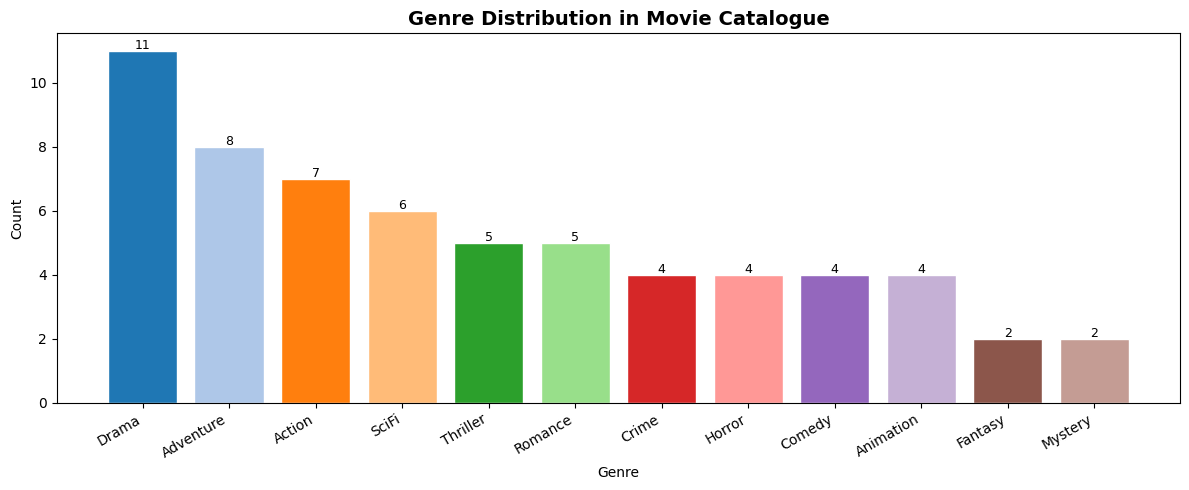


 Screenshot 1 saved: screenshot1_genre_distribution.png


In [32]:
plt.figure(figsize=(12, 5))
all_genres = []
for g in movies['Genre']:
    all_genres.extend(g.split())
genre_counts = pd.Series(all_genres).value_counts().head(12)
bars = plt.bar(genre_counts.index, genre_counts.values,
               color=plt.cm.tab20.colors[:len(genre_counts)], edgecolor='white')
plt.title('Genre Distribution in Movie Catalogue', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('screenshot1_genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Screenshot 1 saved: screenshot1_genre_distribution.png")

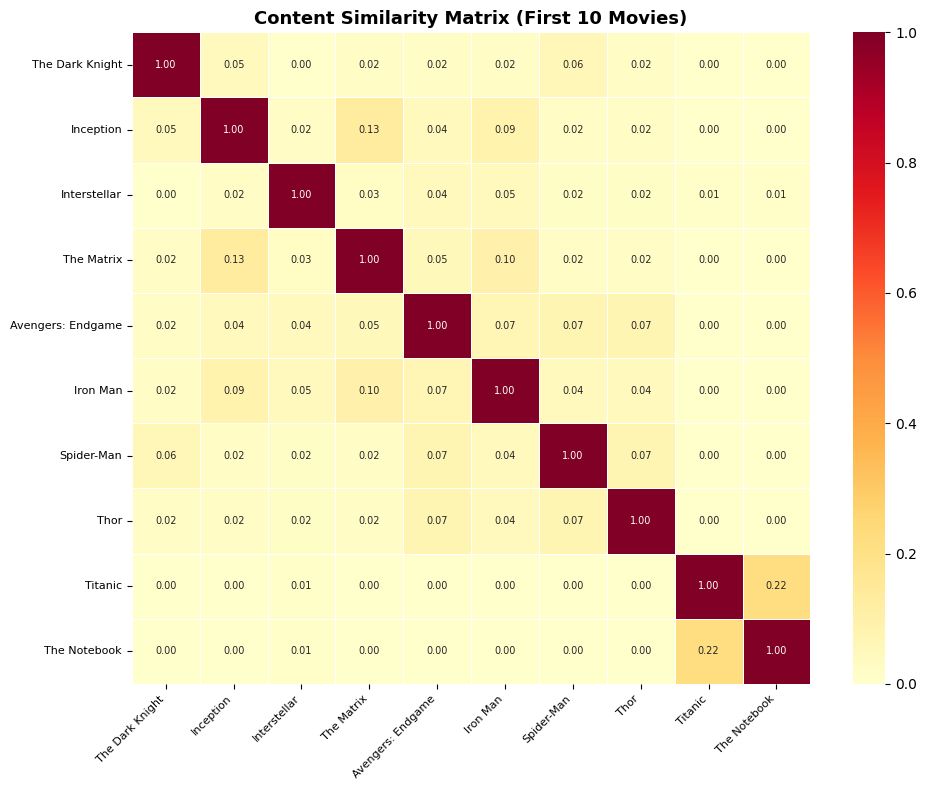

 Screenshot 2 saved: screenshot2_content_similarity.png


In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(content_sim[:10, :10],
            xticklabels=movies['Title'][:10],
            yticklabels=movies['Title'][:10],
            cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Content Similarity Matrix (First 10 Movies)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('screenshot2_content_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Screenshot 2 saved: screenshot2_content_similarity.png")

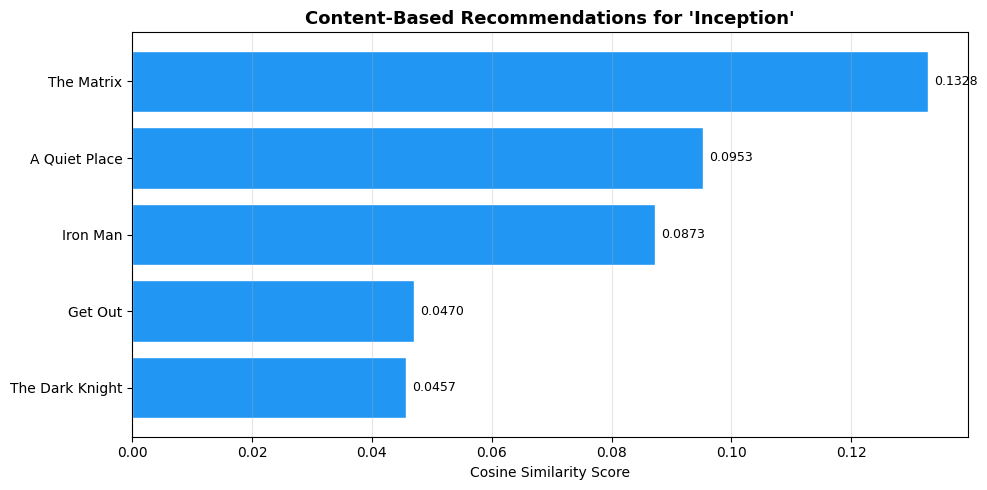

 Screenshot 3 saved: screenshot3_content_recommendations.png


In [34]:
plt.figure(figsize=(10, 5))
if not cb_recs.empty:
    bars = plt.barh(cb_recs['Title'][::-1], cb_recs['Similarity'][::-1],
                    color='#2196F3', edgecolor='white')
    plt.xlabel('Cosine Similarity Score')
    plt.title(f"Content-Based Recommendations for '{test_movie}'",
              fontsize=13, fontweight='bold')
    for bar, val in zip(bars, cb_recs['Similarity'][::-1]):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
    plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('screenshot3_content_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Screenshot 3 saved: screenshot3_content_recommendations.png")


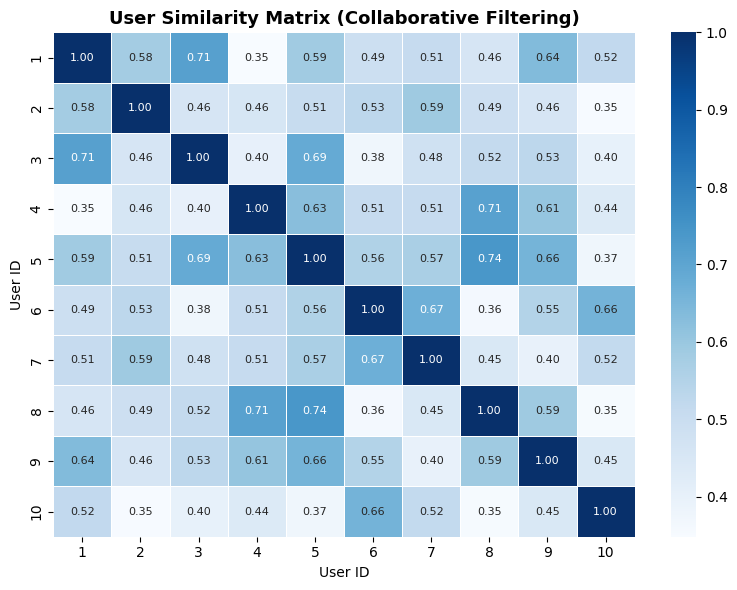

 Screenshot 4 saved: screenshot4_user_similarity.png


In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(user_sim_df, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('User Similarity Matrix (Collaborative Filtering)',
          fontsize=13, fontweight='bold')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.savefig('screenshot4_user_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Screenshot 4 saved: screenshot4_user_similarity.png")

In [36]:
print("\n" + "=" * 60)
print("   All done! 4 screenshots saved.")
print("=" * 60)


   All done! 4 screenshots saved.
